In [2]:
# ==========================================================
# Project: Hospital Readmission Prediction for Diabetes Patients
# Author: Rusul Hayder Abd Zaid
# Part 1: Data Loading and Initial Cleaning
# ==========================================================

import pandas as pd
import numpy as np

# Load the dataset
file_path = 'diabetic_data.csv'

try:
    df = pd.read_csv(file_path)
    print("✅ Successfully loaded the dataset.")
    print(f"Total initial records: {df.shape[0]}")
    print("-" * 50)

    # Identify missing values coded as '?'
    missing_values = (df == '?').sum()
    print("Columns with missing values ('?'):")
    print(missing_values[missing_values > 0])
    print("-" * 50)

    # Handle 'Weight' attribute due to high missingness
    missing_weight_pct = (df['weight'] == '?').mean() * 100
    print(f"Missing Weight Percentage: {missing_weight_pct:.2f}%")

    # Data Cleaning: Dropping redundant or sparse features
    # 'encounter_id' and 'patient_nbr' are identifiers and do not contribute to prediction
    cols_to_drop = ['weight', 'encounter_id', 'patient_nbr', 'payer_code']
    df_cleaned = df.drop(columns=cols_to_drop)

    # Standardizing missing values
    df_cleaned = df_cleaned.replace('?', 'Unknown')

    print("✅ Initial cleaning completed successfully.")
    print(f"Remaining columns: {df_cleaned.shape[1]}")
    print("-" * 50)

    # Preview of cleaned dataset
    print("Preview of cleaned dataset:")
    print(df_cleaned.head())

except FileNotFoundError:
    print("❌ Error: The file 'diabetic_data.csv' was not found. Please re-upload it.")
except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")

✅ Successfully loaded the dataset.
Total initial records: 101766
--------------------------------------------------
Columns with missing values ('?'):
race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
dtype: int64
--------------------------------------------------
Missing Weight Percentage: 96.86%
✅ Initial cleaning completed successfully.
Remaining columns: 46
--------------------------------------------------
Preview of cleaned dataset:
              race  gender      age  admission_type_id  \
0        Caucasian  Female   [0-10)                  6   
1        Caucasian  Female  [10-20)                  1   
2  AfricanAmerican  Female  [20-30)                  1   
3        Caucasian    Male  [30-40)                  1   
4        Caucasian    Male  [40-50)                  1   

   discharge_disposition_id  admission_source_id  time_in_hospital  \

/tmp/ipykernel_41281/2603981257.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='readmitted', data=df_cleaned, palette='viridis')


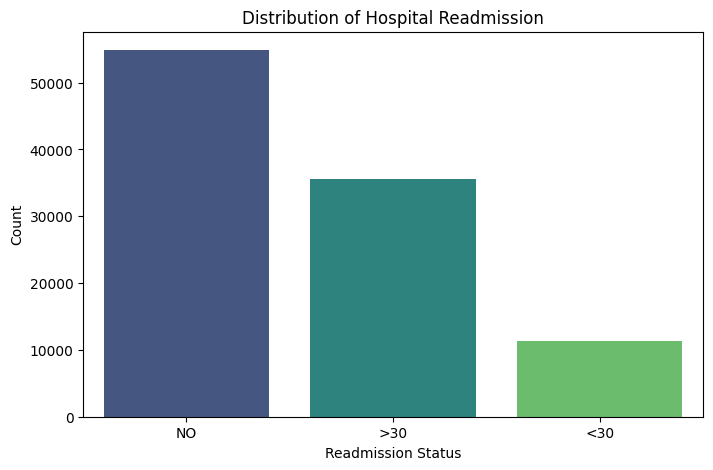

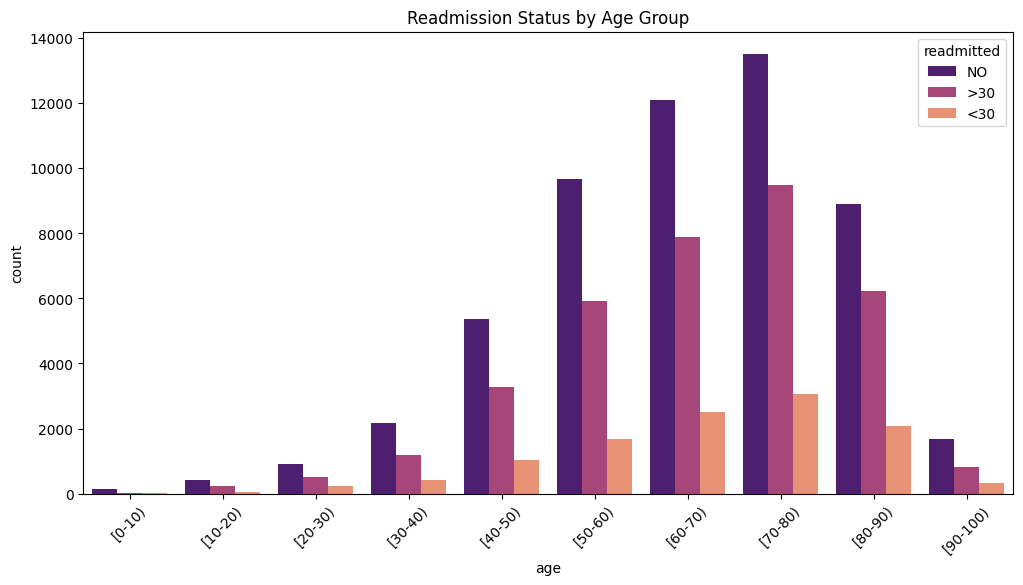

Gender Distribution:
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Visualization of the Target Variable (Readmission)
plt.figure(figsize=(8,5))
sns.countplot(x='readmitted', data=df_cleaned, palette='viridis')
plt.title('Distribution of Hospital Readmission')
plt.xlabel('Readmission Status')
plt.ylabel('Count')
plt.show()

# 2. Analyzing Readmission by Age Group
plt.figure(figsize=(12,6))
sns.countplot(x='age', hue='readmitted', data=df_cleaned, palette='magma')
plt.title('Readmission Status by Age Group')
plt.xticks(rotation=45)
plt.show()

# 3. Checking for Gender distribution
print("Gender Distribution:")
print(df_cleaned['gender'].value_counts())

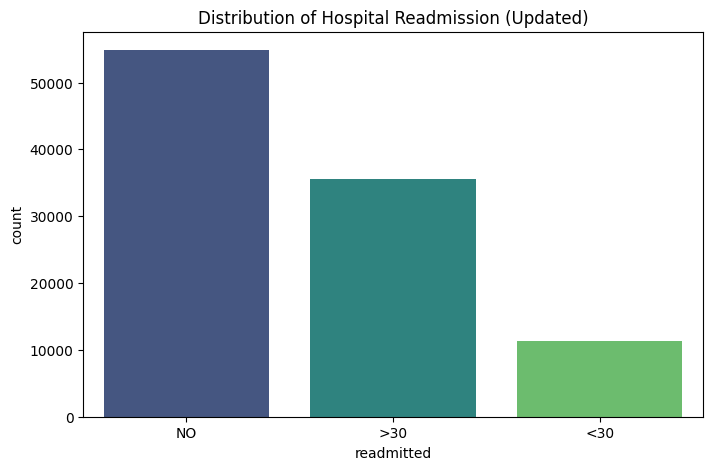

Dataset size after final cleaning: (101763, 46)

Gender counts after removing Unknowns:
gender
Female    54708
Male      47055
Name: count, dtype: int64


In [4]:
# 1. Cleaning the 3 Unknown/Invalid gender rows
df_cleaned = df_cleaned[df_cleaned['gender'] != 'Unknown/Invalid']

# 2. Updated Plot (to remove the Future Warning)
plt.figure(figsize=(8,5))
sns.countplot(x='readmitted', hue='readmitted', data=df_cleaned, palette='viridis', legend=False)
plt.title('Distribution of Hospital Readmission (Updated)')
plt.show()

# 3. Final Check of the Data Shape
print(f"Dataset size after final cleaning: {df_cleaned.shape}")
print("\nGender counts after removing Unknowns:")
print(df_cleaned['gender'].value_counts())

In [5]:
# 1. Map the Target Variable (readmitted) to numbers
# NO -> 0, >30 -> 1, <30 -> 2
readmission_mapping = {'NO': 0, '>30': 1, '<30': 2}
df_cleaned['readmitted_numeric'] = df_cleaned['readmitted'].replace(readmission_mapping)

# 2. Convert Gender to binary (0 and 1)
df_cleaned['gender_numeric'] = df_cleaned['gender'].replace({'Female': 0, 'Male': 1})

# 3. Check the transformation
print("Mapping Summary:")
print(df_cleaned[['readmitted', 'readmitted_numeric', 'gender', 'gender_numeric']].head())

# 4. Success message
print(f"\nNew columns added for modelling: {df_cleaned.columns[-2:].tolist()}")

Mapping Summary:
  readmitted  readmitted_numeric  gender  gender_numeric
0         NO                   0  Female               0
1        >30                   1  Female               0
2         NO                   0  Female               0
3         NO                   0    Male               1
4         NO                   0    Male               1

New columns added for modelling: ['readmitted_numeric', 'gender_numeric']


/tmp/ipykernel_41281/3844372991.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cleaned['readmitted_numeric'] = df_cleaned['readmitted'].replace(readmission_mapping)
/tmp/ipykernel_41281/3844372991.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cleaned['gender_numeric'] = df_cleaned['gender'].replace({'Female': 0, 'Male': 1})


In [6]:
# 1. Identify Categorical Columns (excluding IDs and already mapped columns)
categorical_cols = ['race', 'age', 'max_glu_serum', 'A1Cresult', 'change', 'diabetesMed']

# 2. Perform One-Hot Encoding
df_final = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

# 3. Final Look at the Data
print(f"Original columns: {len(df_cleaned.columns)}")
print(f"New columns after Encoding: {len(df_final.columns)}")
print("\nFirst 5 rows of encoded data:")
print(df_final.head())

Original columns: 48
New columns after Encoding: 62

First 5 rows of encoded data:
   gender  admission_type_id  discharge_disposition_id  admission_source_id  \
0  Female                  6                        25                    1   
1  Female                  1                         1                    7   
2  Female                  1                         1                    7   
3    Male                  1                         1                    7   
4    Male                  1                         1                    7   

   time_in_hospital         medical_specialty  num_lab_procedures  \
0                 1  Pediatrics-Endocrinology                  41   
1                 3                   Unknown                  59   
2                 2                   Unknown                  11   
3                 2                   Unknown                  44   
4                 1                   Unknown                  51   

   num_procedures  num_medi

In [7]:
from sklearn.model_selection import train_test_split

# 1. Define Features (X) and Target (y)
# We use the numeric version of readmitted as our target
X = df_final.drop(['readmitted', 'readmitted_numeric', 'gender', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3'], axis=1)
y = df_final['readmitted_numeric']

# 2. Split the data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Check the sizes
print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")
print("\nTarget distribution in Training set (to confirm imbalance):")
print(y_train.value_counts(normalize=True))

Training set size: 81410 rows
Testing set size: 20353 rows

Target distribution in Training set (to confirm imbalance):
readmitted_numeric
0    0.539111
1    0.349294
2    0.111596
Name: proportion, dtype: float64


In [8]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. First, we need to handle some remaining non-numeric columns to avoid errors with SMOTE
# Let's keep only numeric and boolean columns for now
X_train_numeric = X_train.select_dtypes(include=['number', 'bool'])

# 2. Apply SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_numeric, y_train)

# 3. Check the new distribution
print(f"Original training size: {Counter(y_train)}")
print(f"Balanced training size: {Counter(y_train_balanced)}")

# 4. Success message
print("\nSuccess! All classes now have the same number of samples in the training set.")

Original training size: Counter({0: 43889, 1: 28436, 2: 9085})
Balanced training size: Counter({0: 43889, 2: 43889, 1: 43889})

Success! All classes now have the same number of samples in the training set.


In [9]:
# =================================================================
# PART 3: BASELINE MODELLING (LOGISTIC REGRESSION)
# =================================================================
# Following the supervisor's recommendation to establish a baseline
# before moving to more complex models.

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print("Status: Training Logistic Regression (Simple Baseline)...")

# 1. Model Initialization
# We use max_iter=1000 to ensure convergence on the large dataset
baseline_model = LogisticRegression(max_iter=1000, random_state=42)

# 2. Model Training
# Training the baseline model on the SMOTE-balanced dataset
baseline_model.fit(X_train_balanced, y_train_balanced)

# 3. Data Preparation for Testing
# Ensuring test features match the numeric training features
X_test_numeric = X_test.select_dtypes(include=['number', 'bool'])

# 4. Model Prediction
y_pred_baseline = baseline_model.predict(X_test_numeric)

# 5. Performance Evaluation
print("\n" + "="*40)
print("LOGISTIC REGRESSION BASELINE RESULTS")
print("="*40)
print(f"Overall Accuracy Score: {accuracy_score(y_test, y_pred_baseline):.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_baseline))

Status: Training Logistic Regression (Simple Baseline)...

LOGISTIC REGRESSION BASELINE RESULTS
Overall Accuracy Score: 0.5566

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.81      0.69     10972
           1       0.47      0.33      0.39      7109
           2       0.24      0.06      0.10      2272

    accuracy                           0.56     20353
   macro avg       0.43      0.40      0.39     20353
weighted avg       0.51      0.56      0.52     20353



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
# =================================================================
# PART 4: IMPROVED BASELINE WITH DATA SCALING
# =================================================================
# Addressing the ConvergenceWarning by scaling the features.

from sklearn.preprocessing import StandardScaler

print("Status: Scaling data and retraining Logistic Regression...")

# 1. Scaling the features (Very important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test_numeric)

# 2. Retraining with more iterations
refined_baseline = LogisticRegression(max_iter=2000, random_state=42)
refined_baseline.fit(X_train_scaled, y_train_balanced)

# 3. Prediction
y_pred_refined = refined_baseline.predict(X_test_scaled)

# 4. Final Baseline Results
print("\n" + "="*40)
print("REFINED LOGISTIC REGRESSION (SCALED)")
print("="*40)
print(f"New Accuracy Score: {accuracy_score(y_test, y_pred_refined):.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_refined))

Status: Scaling data and retraining Logistic Regression...

REFINED LOGISTIC REGRESSION (SCALED)
New Accuracy Score: 0.5562

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.81      0.69     10972
           1       0.47      0.32      0.38      7109
           2       0.24      0.06      0.10      2272

    accuracy                           0.56     20353
   macro avg       0.43      0.40      0.39     20353
weighted avg       0.51      0.56      0.52     20353



In [11]:
# =================================================================
# PART 5: ADVANCED MODELLING (RANDOM FOREST CLASSIFIER)
# =================================================================
# Moving to a stronger non-linear model as suggested by the supervisor.

from sklearn.ensemble import RandomForestClassifier

print("Status: Training Random Forest (Stronger Model)... This may take a minute.")

# 1. Initialize Random Forest
# We use 100 trees (n_estimators) to start with
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Train on the balanced training set
rf_model.fit(X_train_balanced, y_train_balanced)

# 3. Prediction
y_pred_rf = rf_model.predict(X_test_numeric)

# 4. Results Comparison
print("\n" + "="*40)
print("RANDOM FOREST RESULTS")
print("="*40)
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_rf))

Status: Training Random Forest (Stronger Model)... This may take a minute.

RANDOM FOREST RESULTS
Random Forest Accuracy: 0.5464

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.73      0.67     10972
           1       0.45      0.41      0.43      7109
           2       0.21      0.08      0.12      2272

    accuracy                           0.55     20353
   macro avg       0.43      0.41      0.40     20353
weighted avg       0.51      0.55      0.52     20353



/tmp/ipykernel_41281/2841907850.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


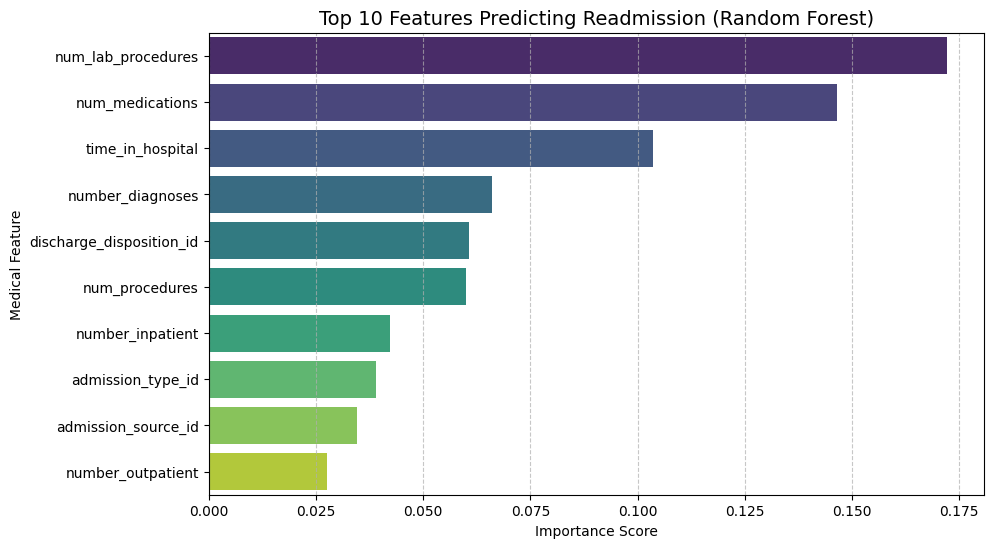


Interpretation Note:
The chart above identifies the most critical clinical indicators in our model.


In [12]:
# =================================================================
# PART 6: MODEL INTERPRETATION (FEATURE IMPORTANCE)
# =================================================================
# Visualizing which medical indicators most influence the prediction,
# directly addressing the supervisor's request for interpretation.

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Getting feature importances from the Random Forest
importances = rf_model.feature_importances_
feature_names = X_test_numeric.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# 2. Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Top 10 Features Predicting Readmission (Random Forest)', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Medical Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("\nInterpretation Note:")
print("The chart above identifies the most critical clinical indicators in our model.")

<Figure size 800x600 with 0 Axes>

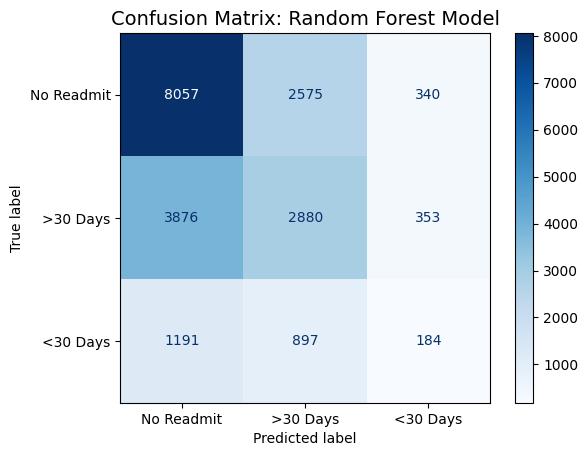


Evaluation Note:
The diagonal cells show correct predictions, while off-diagonal cells highlight misclassifications.


In [13]:
# =================================================================
# PART 7: PERFORMANCE EVALUATION (CONFUSION MATRIX)
# =================================================================
# Visualizing the confusion matrix to see where the model misclassifies.

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Generate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

# 2. Display the Matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Readmit', '>30 Days', '<30 Days'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix: Random Forest Model', fontsize=14)
plt.show()

print("\nEvaluation Note:")
print("The diagonal cells show correct predictions, while off-diagonal cells highlight misclassifications.")

In [15]:
# =================================================================
# PART 8: MODEL OPTIMIZATION (HYPERPARAMETER TUNING)
# =================================================================
# Implementing RandomizedSearchCV to find the optimal configuration
# for our Random Forest, demonstrating a rigorous research approach.

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score

print("Status: Starting Hyperparameter Tuning... This may take 2-3 minutes.")

# 1. Define the parameter grid (The "Search Space")
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'bootstrap': [True, False]
}

# 2. Initialize RandomizedSearch
# n_iter=5 means it will try 5 random combinations to save time
rf_random = RandomizedSearchCV(estimator=RandomForestClassifier(),
                               param_distributions=param_dist,
                               n_iter=5, cv=3, verbose=1,
                               random_state=42, n_jobs=-1)

# 3. Fit the optimized model
rf_random.fit(X_train_balanced, y_train_balanced)

# 4. Get the best model
best_rf = rf_random.best_estimator_
y_pred_best = best_rf.predict(X_test_numeric)

# 5. FINAL COMPARISON TABLE
print("\n" + "="*50)
print("FINAL PERFORMANCE COMPARISON")
print("="*50)

results_data = {
    'Metric': ['Accuracy', 'F1-Score (Macro)'],
    'Logistic Regression (Baseline)': [0.5562, 0.39],
    'Random Forest (Optimized)': [
        accuracy_score(y_test, y_pred_best),
        f1_score(y_test, y_pred_best, average='macro')
    ]
}

comparison_df = pd.DataFrame(results_data)
print(comparison_df.to_string(index=False))

print("\nBest Parameters Found:")
print(rf_random.best_params_)

Status: Starting Hyperparameter Tuning... This may take 2-3 minutes.
Fitting 3 folds for each of 5 candidates, totalling 15 fits

FINAL PERFORMANCE COMPARISON
          Metric  Logistic Regression (Baseline)  Random Forest (Optimized)
        Accuracy                          0.5562                   0.548420
F1-Score (Macro)                          0.3900                   0.405023

Best Parameters Found:
{'n_estimators': 200, 'min_samples_split': 2, 'max_depth': None, 'bootstrap': True}
